# Vision-Language Models (VLMs) from Scratch: Basic Principles Explained

Welcome! If you know some basic Python but have never touched a Vision-Language Model (VLM) before, you are in exactly the right place.


## 1. Introduction: What is a VLM?

Historically, AI models were hyper-specialized. You had "computer vision" models that could detect cars in a photo, and "natural language" models that could translate French to English. But they couldn't talk to each other. 

A **Vision-Language Model (VLM)** is like a perfectly bilingual translator who fluently speaks both "Image" and "Text". By understanding both modalities at the same time, VLMs can perform incredible feats:
* **Visual Question Answering (VQA):** "What color is the umbrella in this photo?"
* **Image Captioning:** Automatically writing "A golden retriever catching a frisbee."
* **Zero-Shot Classification:** Categorizing images into classes the model was never explicitly trained on, just by reading the class names!

**Why this is revolutionary:** We no longer need to train a new, custom AI for every specific visual task. We can just use text to "ask" the vision model what to do!

**Prerequisites for this notebook:**
* Basic Python & NumPy.
* That's it! We will explain the math and the machine learning concepts as we go.

## 2. Core Concepts – The Big Picture

How do we get an image of a dog and the word "dog" to mean the same thing to a computer? 

We use a concept called **Two Towers** and a **Shared Embedding Space**.

Imagine a massive, multidimensional room (the "Shared Embedding Space"). 
1. We send an image through a **Vision Encoder** (Tower 1). Its job is to look at the pixels and assign the image a specific set of coordinates in the room.
2. We send text through a **Text Encoder** (Tower 2). Its job is to look at the words and assign the text a specific set of coordinates in the *exact same room*.

If the model is well-trained, the coordinates for the image of a dog and the text "a photo of a dog" will be right next to each other!

```mermaid
flowchart LR
    I[🖼️ Image] --> VE(Vision Encoder)
    T[📝 Text] --> TE(Text Encoder)
    VE -->|Outputs Image Vector| Space((Shared Vector Space))
    TE -->|Outputs Text Vector| Space
    Space -.->|Matching concepts are pulled together| Space
```

The "secret sauce" that makes this work is Contrastive Learning. It acts like a strict matchmaker: 
it pulls matching image-text pairs closer together in the room, and pushes mismatched pairs far apart.

## 3. Math Made Easy: Embeddings and Similarity

When an encoder outputs "coordinates," we call that an **Embedding** or a **Vector**. It's just a list of numbers. 

To figure out if an image vector and a text vector are pointing to the same concept, we measure the angle between them. This is called **Cosine Similarity**.

### The Math
If we have an image vector $I$ and a text vector $T$, the cosine similarity $S_c(I,T)$ is calculated as:

$$S_c(I,T) = \frac{I \cdot T}{\|I\| \|T\|}$$

* $I \cdot T$ (The dot product): Multiply the matching numbers in the lists together and add them up. If they point in the same direction, this number gets big.
* $\|I\| \|T\|$ (The magnitudes): This just scales the result so the final score is always between **-1** (exact opposites) and **1** (perfect match). A score of **0** means they are completely unrelated.

Let's visualize this with some code!

In [ ]:
# Run this cell to visualize Cosine Similarity!
import numpy as np
import matplotlib.pyplot as plt

def plot_vectors(v1, v2, title, ax):
    ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='blue', label='Image Vector')
    ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='red', label='Text Vector')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Calculate cosine similarity
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    cos_sim = dot_product / (norm_v1 * norm_v2)
    
    ax.set_title(f"{title}\nCosine Sim: {cos_sim}")
    ax.legend(loc='upper left')

# Create our plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 6))

# Scenario 1: Highly aligned (A dog image and "a photo of a dog")
img_vec_1 = np.array([2, 2])
text_vec_1 = np.array([2, 2.3])
plot_vectors(img_vec_1, text_vec_1, "Highly Aligned (Match)", ax1)

# Scenario 2: Poorly aligned (A dog image and "a photo of a car")
img_vec_2 = np.array([2, 2])
text_vec_2 = np.array([-2, 1.9])
plot_vectors(img_vec_2, text_vec_2, "Poorly Aligned (Mismatch)", ax2)

plt.tight_layout()
plt.show()

# What you should see:
# Two graphs. The left graph shows arrows pointing almost the same way (Similarity ~ 1.0).
# The right graph shows arrows pointing apart (Similarity is much lower).

### Try it yourself!
Change the numbers in the cell below to see how cosine similarity changes. Try to make a cosine similarity of exactly `0.0` (Hint: make the vectors perpendicular, like `[0, 2]` and `[2, 0]`).

In [ ]:
# Try it yourself: change these lists of two numbers!
my_image_vector = np.array([1.0, 1.0])
my_text_vector = np.array([1.0, 1.0])

cos_sim = np.dot(my_image_vector, my_text_vector) / (np.linalg.norm(my_image_vector) * np.linalg.norm(my_text_vector))
print(f"Your Cosine Similarity is: {cos_sim:.4f}")

## 4. Hands-on Demo: CLIP (The Classic VLM)

OpenAI's **CLIP** (Contrastive Language-Image Pretraining) is the model that popularized this entire approach. Let's load it up and play with it!

First, we need to install the tools.

### Install libraries and Load Model

In [1]:
# Install the necessary libraries
!pip install -q torch torchvision transformers matplotlib scikit-learn requests Pillow
print("Libraries installed successfully!")
# Import libraries and load the CLIP model from Hugging Face
import torch
import requests
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt

print("Downloading and loading the CLIP model... (this might take a minute)")
model_id = "openai/clip-vit-large-patch14"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)
print("Model loaded!")

Libraries installed successfully!


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Model loaded!


### Load Images

Displaying: Photos/AstonMartinValhalla.jpg
Displaying: Photos/Spitfire_Plane.jpg
Displaying: Photos/Challenger2_MBT.jpg
Displaying: Photos/British_Shorthair_Cat.jpg
Displaying: Photos/Golden_Retriever_Dog.jpg
Displaying: Photos/PanchiKun_Monkey.jpeg


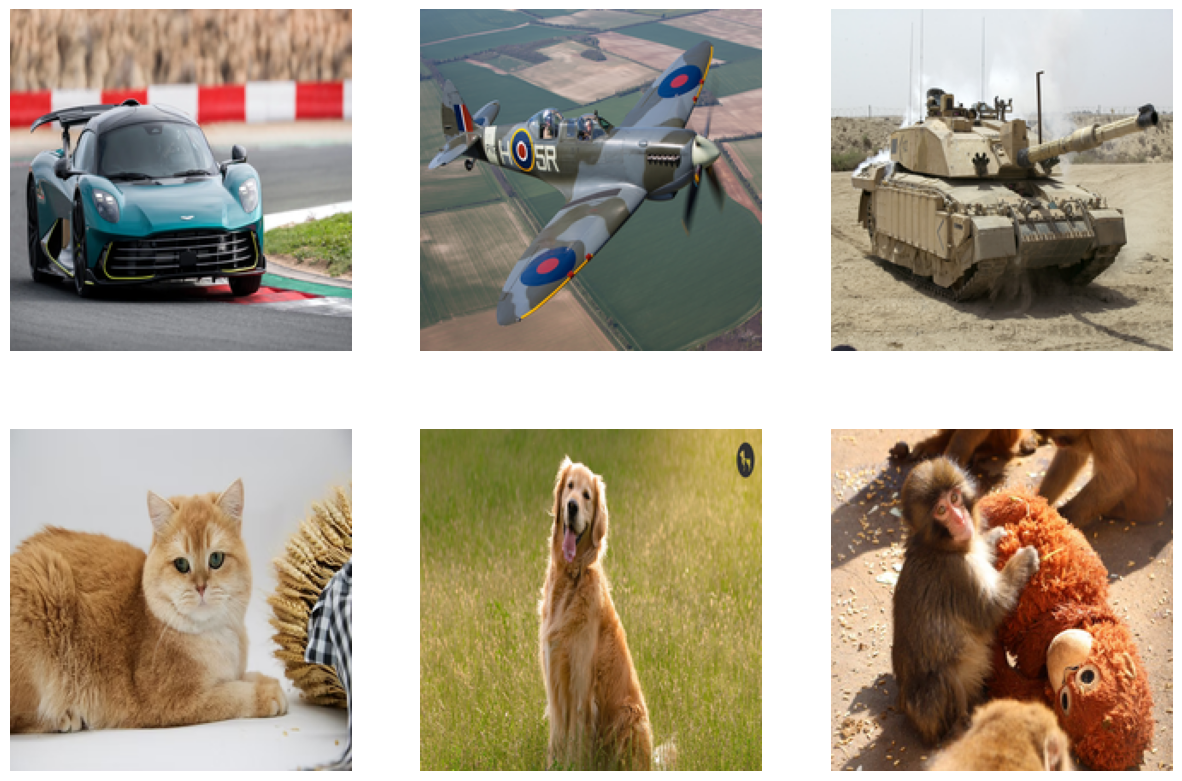

In [24]:
from PIL import Image
import matplotlib.pyplot as plt

# 1. Configuration: Set the uniform size for all images
# Dimensions are represented as [width, height]
target_size = (200, 200)

# 2. Data: List of local file paths for the images
image_paths = [
    "Photos/AstonMartinValhalla.jpg",
    "Photos/Spitfire_Plane.jpg",
    "Photos/Challenger2_MBT.jpg",
    "Photos/British_Shorthair_Cat.jpg",
    "Photos/Golden_Retriever_Dog.jpg",
    "Photos/PanchiKun_Monkey.jpeg"
]

# 3. Processing Loop
processed_images = []

for path in image_paths:
    try:
        # Open the image file
        with Image.open(path) as img:
            # Resize image using Lanczos sampling for high-quality downsampling
            img_resized = img.resize(target_size, Image.Resampling.LANCZOS)
            processed_images.append(img_resized)
            
            # 4. Display the image
            print(f"Displaying: {path}")
            #img_resized.show() # This opens the image in your default viewer
            
    except FileNotFoundError:
        print(f"Error: The file at {path} was not found.")

# Alternative: Display all images in a grid using Matplotlib
plt.figure(figsize=(15, 10))
for i, img in enumerate(processed_images):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis('off') # Hide X and Y axes for a cleaner look
plt.show()

### Demo 1: Compute Image-Text Similarity Scores

Let's feed CLIP an image of a cat ,a dog and four different text descriptions to see which one it thinks is the best match.

In [25]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

# Note: Make sure you have loaded the model and processor before calling this function
# Example:
# from transformers import CLIPProcessor, CLIPModel
# model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
# processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


def CLIP_demo(image, texts):
    """
    Simple CLIP Demo: Compare one image with multiple text descriptions.
    
    This function uses OpenAI's CLIP model to measure how well a given image 
    matches each text description and shows the results visually.
    
    Parameters:
        image  : PIL Image object (the image you want to analyze)
        texts  : List of strings (text descriptions to compare against the image)
    
    Example:
        image = Image.open("cat.jpg")
        texts = ["a photo of a cat", "a photo of a dog", "a photo of a car"]
        CLIP_demo(image, texts)
    """
    
    print("🔄 Processing image and texts for CLIP model...\n")
    
    # 1. Prepare the inputs for the model
    # Convert the image and texts into the format CLIP understands (tensors)
    inputs = processor(
        text=texts, 
        images=image, 
        return_tensors="pt",   # PyTorch tensors
        padding=True
    )
    
    # 2. Run the CLIP model (no training, just inference)
    # torch.no_grad() saves memory and makes it faster
    with torch.no_grad():
        outputs = model(**inputs)
    
    # 3. Convert raw scores (logits) into probabilities (0.0 to 1.0)
    # softmax turns the numbers into percentages that add up to 100%
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]
    
    # 4. Visualize the results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left side: Display the original image
    ax1.imshow(image)
    ax1.axis('off')
    ax1.set_title("Input Image", fontsize=14, fontweight='bold')
    
    # Right side: Bar chart showing match probabilities
    # Highlight the best match in green
    colors = ['green' if p == max(probs) else 'lightgray' for p in probs]
    
    y_pos = range(len(texts))
    ax2.barh(y_pos, probs, color=colors, height=0.6)
    ax2.grid(False)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(texts, fontsize=11)
    ax2.set_xlim(0, 1)
    ax2.invert_yaxis()                    # Best match appears at the top
    ax2.set_title("CLIP Confidence Scores", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Probability (0.0 — 1.0)", fontsize=12)
    
    # Add probability values on the bars
    for i, prob in enumerate(probs):
        ax2.text(prob + 0.02, i, f"{prob*100:.1f}%", 
                va='center', fontsize=11, fontweight='medium')
    
    plt.tight_layout()
    plt.show()
    
    # 5. Print clean text summary
    print("📊 RESULTS SUMMARY:")
    print("-" * 60)
    for text, prob in zip(texts, probs):
        percentage = prob * 100
        print(f"• {text:35} → {percentage:6.2f}%  {'← Best Match' if prob == max(probs) else ''}")
    print("-" * 60)

🚀 Starting Local CLIP Demo!
We will test two local images (Cat and Dog) against these 6 descriptions.

🐱 Testing the LOCAL CAT image...
🔄 Processing image and texts for CLIP model...



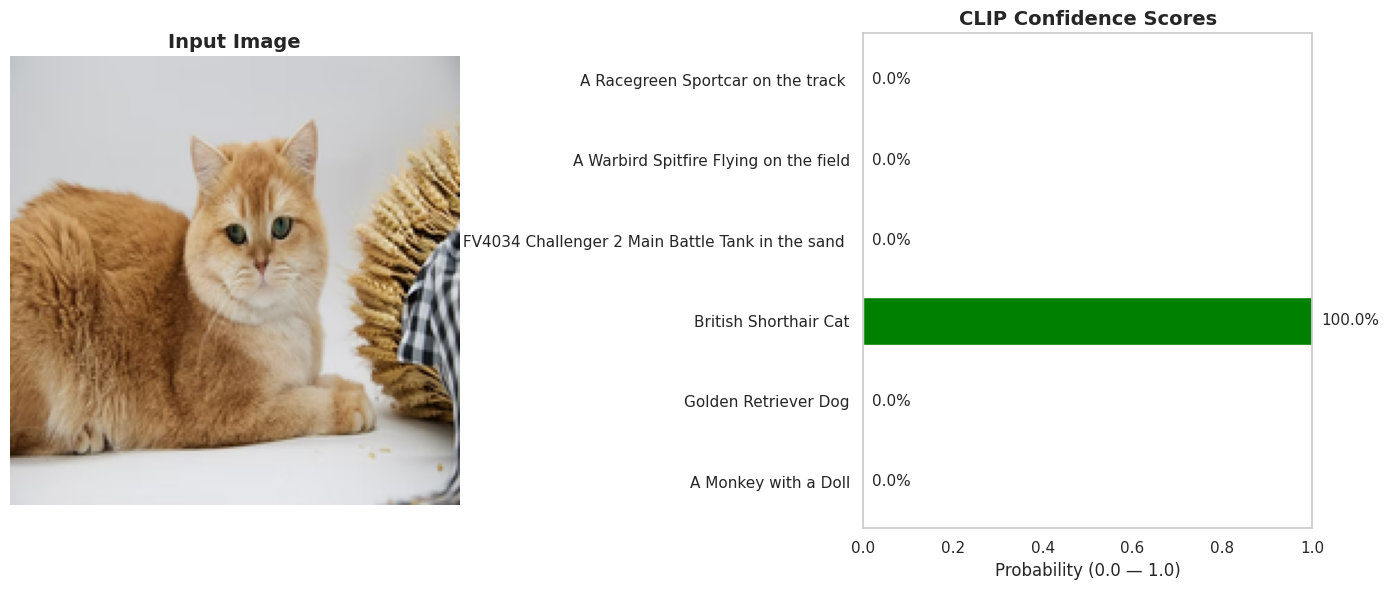

📊 RESULTS SUMMARY:
------------------------------------------------------------
• A Racegreen Sportcar on the track   →   0.00%  
• A Warbird Spitfire Flying on the field →   0.00%  
•  FV4034 Challenger 2 Main Battle Tank in the sand  →   0.00%  
• British Shorthair Cat               → 100.00%  ← Best Match
• Golden Retriever Dog                →   0.00%  
• A Monkey with a Doll                →   0.00%  
------------------------------------------------------------

🐶 Testing the LOCAL DOG image...
🔄 Processing image and texts for CLIP model...



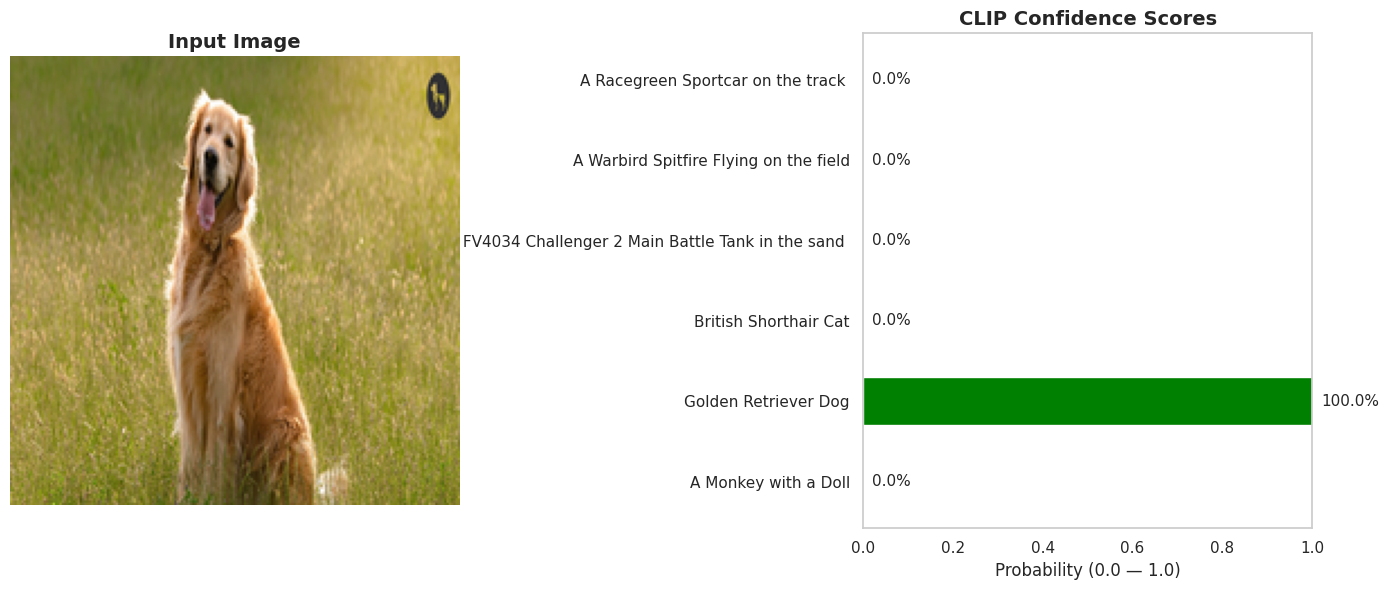

📊 RESULTS SUMMARY:
------------------------------------------------------------
• A Racegreen Sportcar on the track   →   0.00%  
• A Warbird Spitfire Flying on the field →   0.00%  
•  FV4034 Challenger 2 Main Battle Tank in the sand  →   0.00%  
• British Shorthair Cat               →   0.00%  
• Golden Retriever Dog                → 100.00%  ← Best Match
• A Monkey with a Doll                →   0.00%  
------------------------------------------------------------

✅ Demo Completed Successfully!
What you should observe:
• The CAT image should give a very high score to 'British Shorthair Cat'
• The DOG image should give a very high score to 'Golden Retriever Dog'
• Both images should give very low scores to unrelated items like
  'Sportcar AstonMartinValhalla', 'Spitfire Warbird', and 'Challenger Main Battle Tank'
• This shows that CLIP correctly understands what is in each photo! 😄


In [26]:
# ================================================
#   LOCAL CLIP DEMO - Testing with Cat and Dog
# ================================================

# List of text descriptions we want to compare the images against
texts = [
    "A Racegreen Sportcar on the track ",
    "A Warbird Spitfire Flying on the field",
    " FV4034 Challenger 2 Main Battle Tank in the sand ",
    "British Shorthair Cat",
    "Golden Retriever Dog",
    "A Monkey with a Doll"
    
]

print("🚀 Starting Local CLIP Demo!")
print("=" * 70)
print("We will test two local images (Cat and Dog) against these 6 descriptions.")
print("=" * 70)

# ------------------- Test the Cat Image -------------------
print("\n🐱 Testing the LOCAL CAT image...")

# processed_images[3] is the cat image (from earlier processing)
CLIP_demo(processed_images[3], texts)

# ------------------- Test the Dog Image -------------------
print("\n🐶 Testing the LOCAL DOG image...")

# processed_images[4] is the dog image
CLIP_demo(processed_images[4], texts)

# ------------------- Final Message -------------------
print("\n" + "=" * 70)
print("✅ Demo Completed Successfully!")
print("=" * 70)

print("What you should observe:")
print("• The CAT image should give a very high score to 'British Shorthair Cat'")
print("• The DOG image should give a very high score to 'Golden Retriever Dog'")
print("• Both images should give very low scores to unrelated items like")
print("  'Sportcar AstonMartinValhalla', 'Spitfire Warbird', and 'Challenger Main Battle Tank'")
print("• This shows that CLIP correctly understands what is in each photo! 😄")

### Trick Clip

🔄 Processing image and texts for CLIP model...



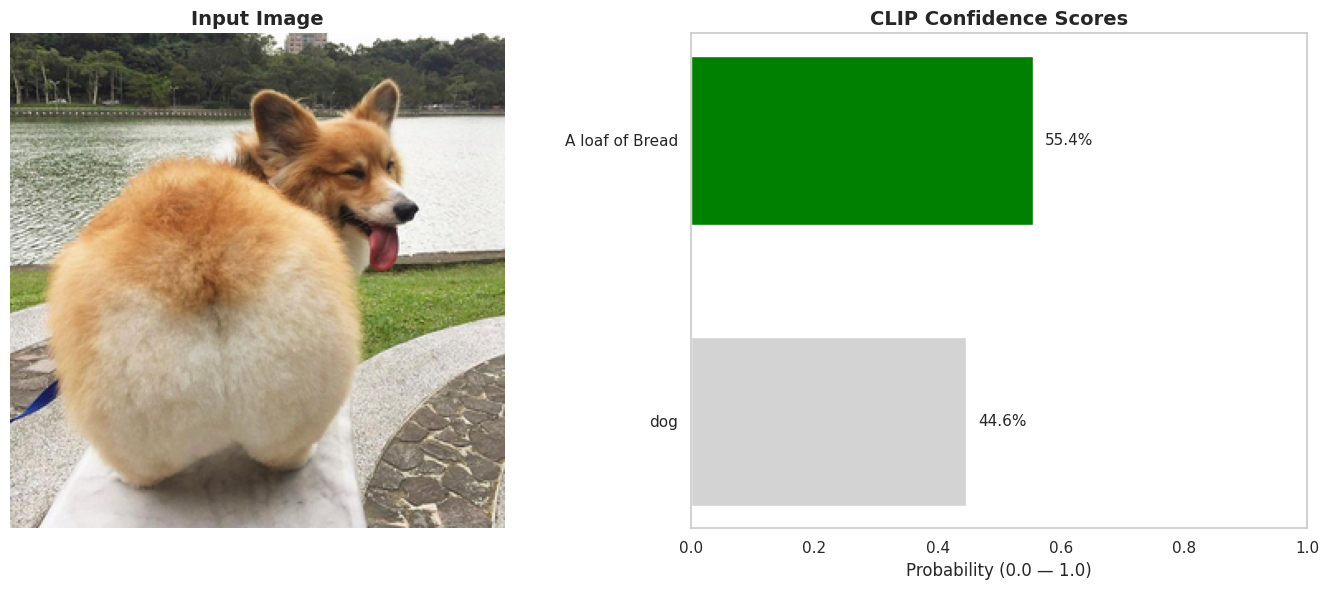

📊 RESULTS SUMMARY:
------------------------------------------------------------
• A loaf of Bread                     →  55.42%  ← Best Match
• dog                                 →  44.58%  
------------------------------------------------------------


In [27]:
target_size = [300,300]
image_path = "Photos/Corgi_butts.jpg"
with Image.open(image_path) as img:
    img_resized = img.resize(target_size, Image.Resampling.LANCZOS)
User_text1 = ["A loaf of Bread", "dog"]
CLIP_demo(img_resized, User_text1)

### Try it yourself!
Find an image  on Google, paste the path below, and write your own text descriptions to see if you can trick CLIP.

In [ ]:
target_size = [300,300]
# 1. Image Path
image_path = "PASTE_IMAGE_PATH_HERE"
with Image.open(image_path) as img:
    img_resized = img.resize(target_size, Image.Resampling.LANCZOS)

# 2. Define our candidate text descriptions
User_text2 = ["description 1", "description 2", "description 3"]
CLIP_demo(img_resized, User_text2)

### Demo 2: Pretraining‑Free Image Classification

Traditional models needed thousands of labeled images to learn a new class (like "airplane"). 

With CLIP, we just give it an image and a list of classes formatted as sentences (`"a photo of a {class}"`). Whichever sentence has the highest similarity score becomes our prediction!

🚀 Starting Local CLIP Demo
Testing image : <PIL.Image.Image image mode=RGB size=300x300 at 0x7A47F560AF90>
Categories    : ['Car', 'Plane', 'Tank', 'Cat', 'Dog', 'Monkey']
🔄 Processing image and texts for CLIP model...



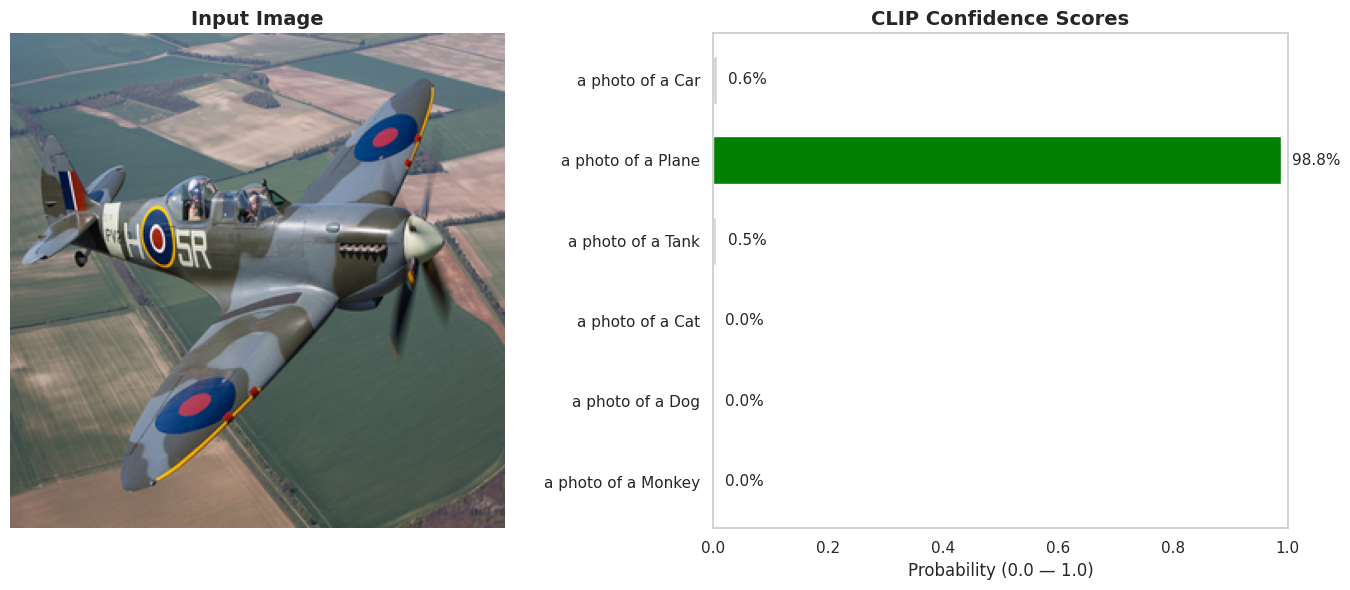

📊 RESULTS SUMMARY:
------------------------------------------------------------
• a photo of a Car                    →   0.61%  
• a photo of a Plane                  →  98.84%  ← Best Match
• a photo of a Tank                   →   0.51%  
• a photo of a Cat                    →   0.02%  
• a photo of a Dog                    →   0.01%  
• a photo of a Monkey                 →   0.00%  
------------------------------------------------------------

🎯 Final Prediction Result
The image is most likely a **Plane**
Confidence     : 98.8%

✅ Process completed successfully!


In [28]:
"""
Pretraining‑Free Image Classification Demo
"""
import numpy as np
from PIL import Image
import torch

# =============================================
# 1. Setup - Define file and categories
# =============================================

target_size = [300,300]
image_path = "Photos/Spitfire_Plane.jpg"
with Image.open(image_path) as img:
    img_resized = img.resize(target_size, Image.Resampling.LANCZOS)

classes = [
    "Car",
    "Plane",
    "Tank",
    "Cat",
    "Dog",
    "Monkey"
]

# =============================================
# 2. Create descriptive prompts for CLIP
# =============================================
prompts = [f"a photo of a {c}" for c in classes]

# =============================================
# 3. Show starting information
# =============================================
print("🚀 Starting Local CLIP Demo")
print("=" * 60)
print(f"Testing image : {img_resized}")
print(f"Categories    : {classes}")
print("=" * 60)

# =============================================
# 4. Run the main CLIP analysis and visualization
# =============================================
# This function handles the core CLIP processing and displays the bar chart
CLIP_demo(img_resized, prompts)

# =============================================
# 5. Detailed Prediction Summary (Winner)
# =============================================
print("\n" + "=" * 60)
print("🎯 Final Prediction Result")
print("=" * 60)

# Prepare inputs for CLIP model
inputs = processor(
    text=prompts,
    images=img_resized,
    return_tensors="pt",
    padding=True
)

# Get predictions from the model
with torch.no_grad():
    outputs = model(**inputs)

# Convert logits to probabilities
probs = outputs.logits_per_image.softmax(dim=1).cpu().numpy()[0]

# Find the best prediction
best_idx = np.argmax(probs)
best_class = classes[best_idx]
best_prob = probs[best_idx] * 100

# Display the result clearly
print(f"The image is most likely a **{best_class}**")
print(f"Confidence     : {best_prob:.1f}%")
print("=" * 60)

print("\n✅ Process completed successfully!")

### Demo 3: Visualizing the Cosine Similarity

#### 3.1 Get All Vectors (Image and Text)

In [29]:
"""
Image and Text Feature Extraction using CLIP
============================================

This script takes images and text descriptions, and extracts their features 
using a CLIP model. Features are then converted to numpy arrays for easy use.
"""

import torch
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------------------------
# Prepare Inputs for the Model
# ------------------------------------------------------------------------------

# Convert images and texts into the format the model expects
image_inputs = processor(
    images=processed_images, 
    return_tensors="pt", 
    padding=True
)

text_inputs = processor(
    text=texts, 
    return_tensors="pt", 
    padding=True
)

# ------------------------------------------------------------------------------
# Extract Features using CLIP Model
# ------------------------------------------------------------------------------

# Disable gradient calculation (we are only doing inference, not training)
with torch.no_grad():
    # Get feature vectors for images
    image_features = model.get_image_features(**image_inputs)
    
    # Get feature vectors for texts
    text_features = model.get_text_features(**text_inputs)

# ------------------------------------------------------------------------------
# Convert Features to NumPy Arrays
# ------------------------------------------------------------------------------

# Move features from GPU to CPU and convert to numpy
np_image_features = image_features.pooler_output.detach().cpu().numpy()
np_text_features = text_features.pooler_output.detach().cpu().numpy()

# ------------------------------------------------------------------------------
# Display Results
# ------------------------------------------------------------------------------

print("Image Features Shape:", np_image_features.shape)
print("Text Features Shape: ", np_text_features.shape)
print("\n" + "="*60)

print("Image Features:")
print(np_image_features)
print("\n" + "-"*60)

print("Text Features:")
print(np_text_features)
# Convert images and texts into the format the model expects

Image Features Shape: (6, 768)
Text Features Shape:  (6, 768)

Image Features:
[[ 0.7238858  -0.22833925  0.5417457  ...  0.29458874 -0.01767159
   0.11671454]
 [-0.11820306 -0.47721243  1.0776998  ...  0.91776717 -0.39518043
  -0.62294936]
 [ 0.16522929 -0.81854516 -0.26846704 ...  0.30444112 -0.2781449
  -0.6810472 ]
 [-0.55038565  0.6976444   0.29692072 ... -0.44657034  0.07046869
   0.13316996]
 [ 0.09487014  1.0718963  -0.3574211  ...  0.21062464  0.5634694
  -0.16131893]
 [-0.6951282   0.7682008  -0.37645537 ... -0.00135639 -0.33351362
   0.93037677]]

------------------------------------------------------------
Text Features:
[[ 0.22688396 -0.16784355  0.42567575 ... -0.5555403   0.34644595
   0.1637043 ]
 [ 0.29791582 -0.5065301   0.3824439  ...  0.13302787 -0.02194087
  -0.1814469 ]
 [-0.9381362  -0.18402815 -0.2326065  ...  0.07273672 -0.16829994
  -0.24656555]
 [-0.19390748  0.5325738  -0.02148924 ... -0.40210313 -0.03628153
  -0.5656971 ]
 [-0.2450398   0.28596896  0.076861

#### 3.2 Data Visualization (Heatmap)

The script uses Seaborn and Matplotlib to turn these raw numbers into a heatmap:

**Color Mapping:** It uses the viridis colormap, where brighter colors usually represent higher similarity scores.

**Thresholding:** By setting vmin=0 and vmax=0.25, we are tuning the contrast of the heatmap to highlight subtle differences in similarity.

**Annotation:** The annot=True flag prints the actual similarity scores directly inside the cells for precise reading.

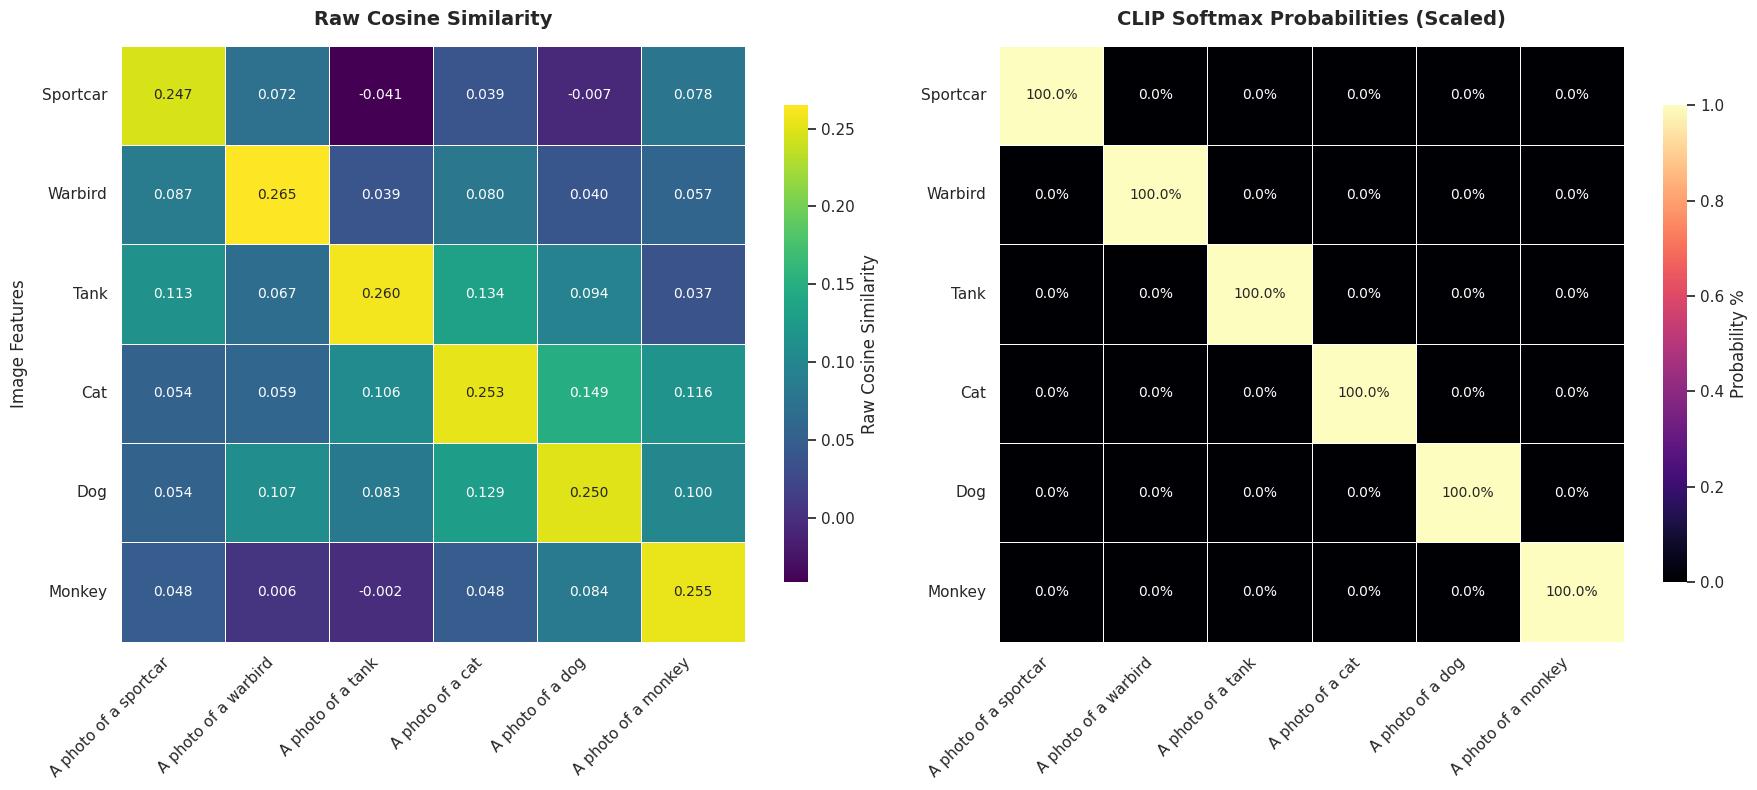

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.special import softmax
# ================================================================
# STEP 1: Calculate Cosine Similarities
# ================================================================

def cosine_similarity_matrix(image_features, text_features):
    """
    Compute cosine similarity matrix between all image and text features efficiently.
    """
    # Normalize features along the feature dimension
    img_norm = image_features / np.linalg.norm(image_features, axis=1, keepdims=True)
    text_norm = text_features / np.linalg.norm(text_features, axis=1, keepdims=True)
    
    # Matrix multiplication of normalized vectors = cosine similarity
    cos_sims = np.dot(img_norm, text_norm.T)
    return cos_sims

cos_sims = cosine_similarity_matrix(np_image_features, np_text_features)

# ================================================================
# STEP 2: Apply CLIP Logit Scaling & Softmax
# ================================================================
# CLIP models use a temperature scalar (often ~100.0) before applying Softmax
logit_scale = 100.0
scaled_logits = cos_sims * logit_scale

# Calculate probabilities across the text descriptions for each image
# axis=1 means: "For this image, what is the probability of each text?"
probabilities = softmax(scaled_logits, axis=1)

# ================================================================
# STEP 3: Define Labels
# ================================================================

row_labels = ["Sportcar", "Warbird", "Tank", "Cat", "Dog", "Monkey"]
col_labels = [f"A photo of a {label.lower()}" for label in row_labels]

# ================================================================
# STEP 4: Dual Heatmap Visualization
# ================================================================

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

# Create a 1x2 grid to show Raw Cosine vs Probabilities
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Plot 1: Raw Cosine Similarity ---
sns.heatmap(
    cos_sims,
    annot=True, fmt=".3f", cmap="viridis", linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Raw Cosine Similarity', 'shrink': 0.8},
    ax=axes[0],
    vmin=cos_sims.min(), vmax=cos_sims.max() # Dynamic scaling based on actual min/max
)
axes[0].set_title("Raw Cosine Similarity", pad=15, fontweight='bold')
axes[0].set_xticks(np.arange(len(col_labels)) + 0.5)
axes[0].set_yticks(np.arange(len(row_labels)) + 0.5)
axes[0].set_xticklabels(col_labels, rotation=45, ha="right")
axes[0].set_yticklabels(row_labels, rotation=0)
axes[0].set_ylabel("Image Features", labelpad=10)

# --- Plot 2: Softmax Probabilities ---
sns.heatmap(
    probabilities,
    annot=True, fmt=".1%", cmap="magma", linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Probability %', 'shrink': 0.8},
    ax=axes[1],
    vmin=0.0, vmax=1.0 # Probabilities are always 0 to 1
)
axes[1].set_title("CLIP Softmax Probabilities (Scaled)", pad=15, fontweight='bold')
axes[1].set_xticks(np.arange(len(col_labels)) + 0.5)
axes[1].set_yticks(np.arange(len(row_labels)) + 0.5)
axes[1].set_xticklabels(col_labels, rotation=45, ha="right")
axes[1].set_yticklabels(row_labels, rotation=0)

# Fine-tune layout
fig.tight_layout()
plt.show()

### Demo 3: Visualizing the Shared Embedding Space (PCA)

We talked about the "Shared Room" where text and images live. In reality, this room has 768 dimensions (way too many for our puny human brains to see). 

We can use a math trick called **PCA** (Principal Component Analysis) to squash those 768 dimensions down to just 2 dimensions so we can draw it on a flat graph. Let's see if matching texts and images actually sit close to each other!

🔹 Step 1: Normalizing features to unit vectors (required for CLIP)...
🔹 Step 2: Centering both modalities to remove the modality gap...
   → 6 image embeddings + 6 text embeddings = 12 total points
🔹 Step 3: Running PCA to project everything into 2D...
   ✅ PCA finished! PC1 explains 19.7% of variance
   ✅ PC2 explains 16.2% of variance
🔹 Step 4: Creating the plot...


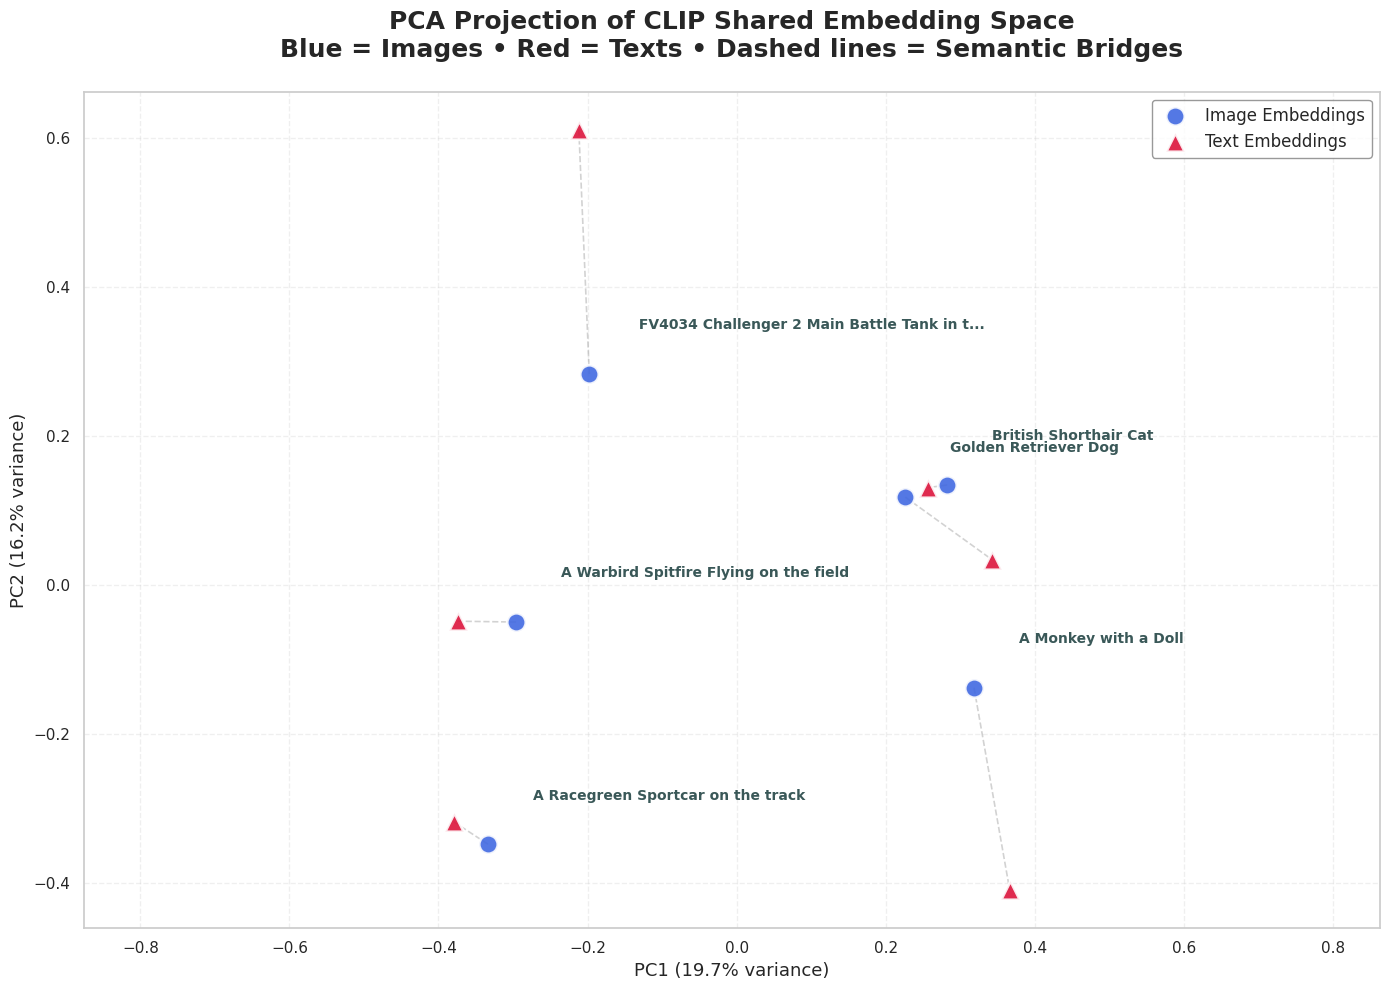

🎉 Visualization complete!


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ================================================================
# 1. PREPARE AND NORMALIZE DATA
# ================================================================
print("🔹 Step 1: Normalizing features to unit vectors (required for CLIP)...")

# CLIP works with cosine similarity → every vector must have length = 1
img_norm = np_image_features / np.linalg.norm(np_image_features, axis=1, keepdims=True)
text_norm = np_text_features / np.linalg.norm(np_text_features, axis=1, keepdims=True)

# ================================================================
# 2. CLOSE THE "MODALITY GAP" (important trick!)
# ================================================================
print("🔹 Step 2: Centering both modalities to remove the modality gap...")

# Image and text embeddings often sit in slightly different regions.
# Subtracting the mean of each group moves both clouds to the exact same center.
# This makes the visualization much clearer and improves alignment visibility.
img_centered = img_norm - img_norm.mean(axis=0)
text_centered = text_norm - text_norm.mean(axis=0)

# Combine everything for PCA (images first, then texts)
all_features = np.vstack((img_centered, text_centered))
n_samples = len(np_image_features)

print(f"   → {n_samples} image embeddings + {n_samples} text embeddings = {all_features.shape[0]} total points")

# ================================================================
# 3. APPLY PCA (2D projection)
# ================================================================
print("🔹 Step 3: Running PCA to project everything into 2D...")

pca = PCA(n_components=2, random_state=42)
features_2d = pca.fit_transform(all_features)

# Split the 2D points back into images and texts
img_2d = features_2d[:n_samples]
text_2d = features_2d[n_samples:]

print(f"   ✅ PCA finished! PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
print(f"   ✅ PC2 explains {pca.explained_variance_ratio_[1]:.1%} of variance")

# ================================================================
# 4. CREATE THE BEAUTIFUL VISUALIZATION
# ================================================================
print("🔹 Step 4: Creating the plot...")

plt.figure(figsize=(14, 10))

# Plot IMAGE points (blue circles)
plt.scatter(img_2d[:, 0], img_2d[:, 1],
            c='royalblue', marker='o', s=180,
            label='Image Embeddings',
            edgecolors='white', linewidth=2, alpha=0.9, zorder=3)

# Plot TEXT points (red triangles)
plt.scatter(text_2d[:, 0], text_2d[:, 1],
            c='crimson', marker='^', s=180,
            label='Text Embeddings',
            edgecolors='white', linewidth=2, alpha=0.9, zorder=3)

# Draw connecting lines + clean labels for every pair
for i in range(n_samples):
    # Semantic bridge line (shows alignment between image and text)
    plt.plot([img_2d[i, 0], text_2d[i, 0]],
             [img_2d[i, 1], text_2d[i, 1]],
             color='gray', linestyle='--', alpha=0.35, linewidth=1.2, zorder=1)
    
    # Label (only once per pair, from the image side – cleaner!)
    caption = texts[i]
    if len(caption) > 45:
        caption = caption[:42] + "..."
    plt.text(img_2d[i, 0] + 0.06, img_2d[i, 1] + 0.06,
             caption,
             fontsize=10, fontweight='bold', color='darkslategray',
             alpha=0.95, zorder=4)

# Final plot styling
plt.title("PCA Projection of CLIP Shared Embedding Space\n"
          "Blue = Images • Red = Texts • Dashed lines = Semantic Bridges",
          fontsize=18, pad=25, fontweight='bold')

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=13)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=13)

plt.legend(frameon=True, facecolor='white', edgecolor='gray', fontsize=12, loc='best')
plt.grid(True, linestyle='--', alpha=0.3)

# Keep natural proportions
plt.gca().set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()

print("🎉 Visualization complete!")

### Demo 4: UMAP (Uniform Manifold Approximation and Projection)

**Why UMAP is better than PCA for visualizing CLIP embeddings**

Principal Component Analysis (PCA) is a simple linear method that finds the directions of greatest variance and projects the data onto them. However, CLIP embeddings live on a highly nonlinear manifold because they come from deep neural nets that capture complex semantic relationships between images and text. As a result, PCA often squashes meaningful clusters and distorts local neighborhoods when reduced to 2D.

**UMAP** (Uniform Manifold Approximation and Projection) is a nonlinear manifold-learning technique that does a much better job. It works in two main steps:

1. It builds a fuzzy topological graph of the high-dimensional data by connecting each point to its nearest neighbors with a smooth distance kernel (so close points have strong connections, far points have weak or none).  
2. It then optimizes a low-dimensional layout (usually 2D) that minimizes the cross-entropy between the high-dimensional graph and the new 2D graph, preserving both local neighborhoods and the overall global structure.

This produces cleaner, more separated clusters and more interpretable visualizations of CLIP embeddings than PCA ever could.

🔹 Step 1: Normalizing features to unit vectors (required for CLIP)...
🔹 Step 2: Centering both modalities to remove the modality gap...
   → 6 image embeddings + 6 text embeddings = 12 total points
🔹 Step 3: Running UMAP to project everything into 2D...
   ✅ UMAP finished! Ready to visualize.
🔹 Step 4: Creating the plot...


/home/joehku/anaconda3/envs/LLM/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


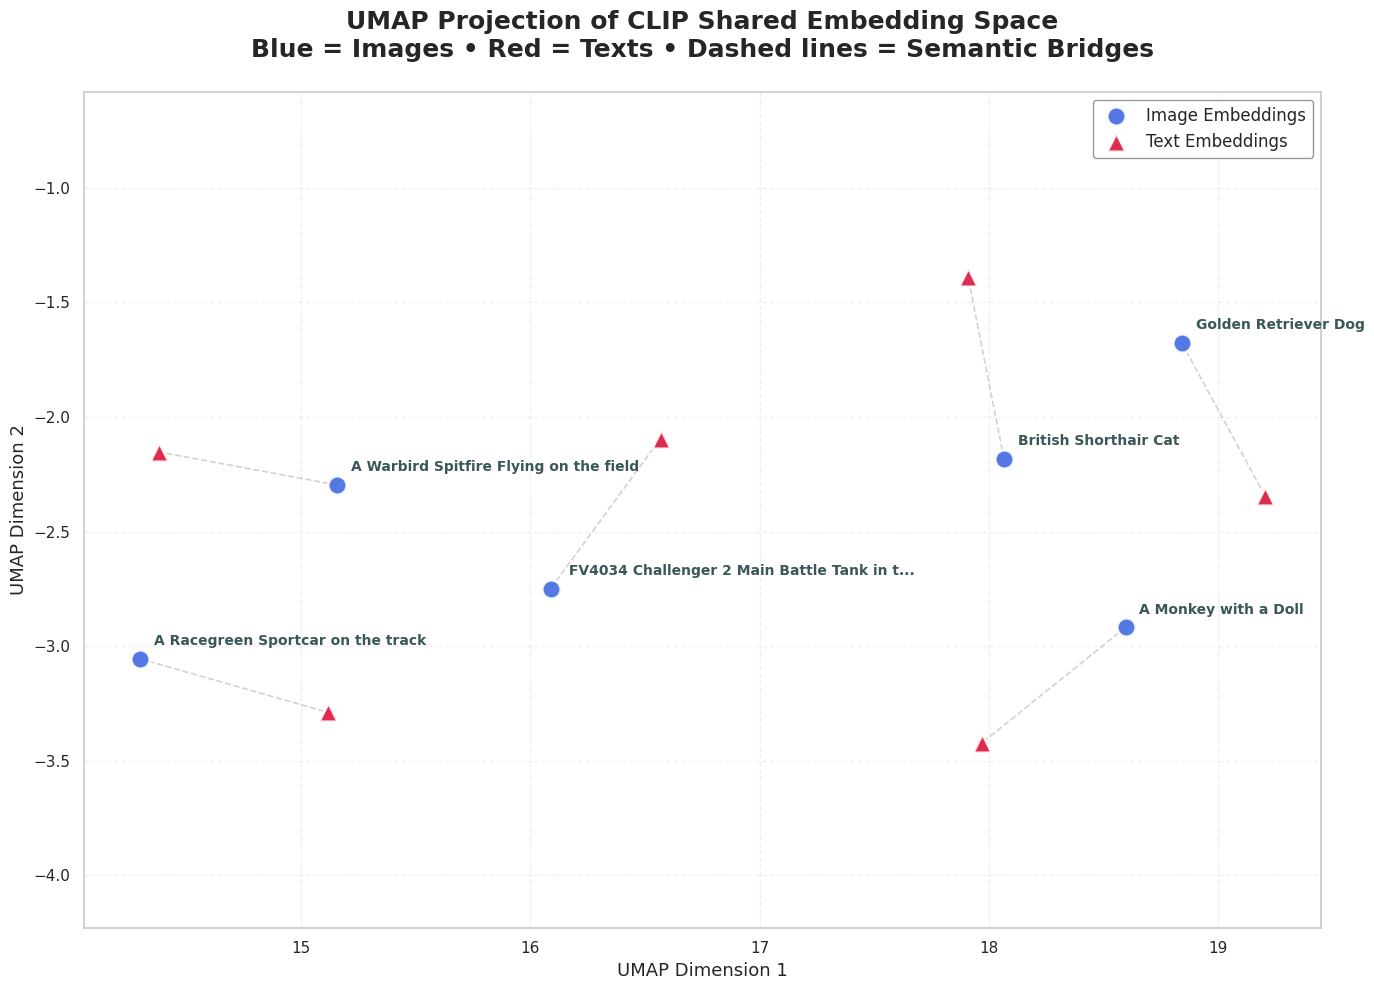

🎉 Visualization complete!


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import umap

# ================================================================
# 1. PREPARE AND NORMALIZE DATA
# ================================================================
print("🔹 Step 1: Normalizing features to unit vectors (required for CLIP)...")

# CLIP uses cosine similarity → we must make every vector length = 1
img_norm = np_image_features / np.linalg.norm(np_image_features, axis=1, keepdims=True)
text_norm = np_text_features / np.linalg.norm(np_text_features, axis=1, keepdims=True)

# ================================================================
# 2. CLOSE THE "MODALITY GAP" (very important trick!)
# ================================================================
print("🔹 Step 2: Centering both modalities to remove the modality gap...")

# Image embeddings and text embeddings often live in slightly different parts of the space.
# Subtracting the mean of each group moves both clouds to the same center.
# This makes the visualization much cleaner and more accurate.
img_centered = img_norm - img_norm.mean(axis=0)
text_centered = text_norm - text_norm.mean(axis=0)

# Combine everything for UMAP (images on top, texts on bottom)
all_features = np.vstack((img_centered, text_centered))
n_samples = len(np_image_features)   # how many image-text pairs we have

print(f"   → {n_samples} image embeddings + {n_samples} text embeddings = {all_features.shape[0]} total points")

# ================================================================
# 3. APPLY UMAP (2D projection)
# ================================================================
print("🔹 Step 3: Running UMAP to project everything into 2D...")

# Easy-to-understand parameter explanations:
reducer = umap.UMAP(
    n_neighbors=5,      # Small number = focus on local clusters (good for CLIP)
    min_dist=0.3,       # How spread out points can be (0.3 gives nice separation)
    metric='cosine',    # The correct distance for CLIP embeddings
    random_state=42,    # Makes results exactly the same every time you run it
)

features_2d = reducer.fit_transform(all_features)

# Split the 2D points back into images and texts
img_2d = features_2d[:n_samples]
text_2d = features_2d[n_samples:]

print("   ✅ UMAP finished! Ready to visualize.")

# ================================================================
# 4. CREATE THE BEAUTIFUL VISUALIZATION
# ================================================================
print("🔹 Step 4: Creating the plot...")

plt.figure(figsize=(14, 10))  # nice big canvas

# Plot IMAGE points (blue circles)
plt.scatter(img_2d[:, 0], img_2d[:, 1],
            c='royalblue', marker='o', s=180,
            label='Image Embeddings',
            edgecolors='white', linewidth=2, alpha=0.9, zorder=3)

# Plot TEXT points (red triangles)
plt.scatter(text_2d[:, 0], text_2d[:, 1],
            c='crimson', marker='^', s=180,
            label='Text Embeddings',
            edgecolors='white', linewidth=2, alpha=0.9, zorder=3)

# Draw connecting lines + labels for every pair
for i in range(n_samples):
    # Semantic bridge line (shows how well image and text are aligned)
    plt.plot([img_2d[i, 0], text_2d[i, 0]],
             [img_2d[i, 1], text_2d[i, 1]],
             color='gray', linestyle='--', alpha=0.35, linewidth=1.2, zorder=1)
    
    # Label (truncated so it doesn't get too long and messy)
    caption = texts[i]
    if len(caption) > 45:
        caption = caption[:42] + "..."
    plt.text(img_2d[i, 0] + 0.06, img_2d[i, 1] + 0.06,
             caption,
             fontsize=10, fontweight='bold', color='darkslategray',
             alpha=0.95, zorder=4)

# Final plot styling
plt.title("UMAP Projection of CLIP Shared Embedding Space\n"
          "Blue = Images • Red = Texts • Dashed lines = Semantic Bridges",
          fontsize=18, pad=25, fontweight='bold')

plt.xlabel("UMAP Dimension 1", fontsize=13)
plt.ylabel("UMAP Dimension 2", fontsize=13)

plt.legend(frameon=True, facecolor='white', edgecolor='gray', fontsize=12, loc='best')
plt.grid(True, linestyle='--', alpha=0.3)

# Keep the shape natural (important for cosine space)
plt.gca().set_aspect('equal', adjustable='datalim')

plt.tight_layout()

# Optional: save a high-quality version
# plt.savefig("clip_umap_visualization.png", dpi=300, bbox_inches='tight')

plt.show()

print("🎉 Visualization complete!")